# Drought Response

Oil palm originates from the Ivory Coast which is a relatively dry area (multiple months of precipitation below 70 mm is typical) with a dry and a wet season.

As a response to drought oil palm can delay the opening of it's new fronds, lower the fraction of female inflorescences and in the more extreme cases abort inflorescences and stop bunch growth (bunch failure).

This example concerns the calibration ofthe modelled drought response.

In [1]:
import sys
import os
sys.path.append('../PalmSim')
sys.path.append('../PalmSim/components')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
matplotlib.style.use('seaborn-colorblind')

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import yaml

In [3]:
from PalmField import PalmField
from Plotter import Plotter

In [4]:
from PalmField import CLASSES

In [52]:
import datetime
wdf = pd.read_excel('..\\..\\experimental\\ghana_yield_variation\\ghana.xlsx')
years = wdf['Year']
months = wdf['Month']

s = [datetime.datetime(year=year,month=month,day=1) 
      for year,month in zip(years,months)]

wdf['datetime'] = s

wdf = wdf.set_index(wdf['datetime'])
del wdf['datetime']

In [60]:
rainfall = list(wdf['Rainfall (mm)'].mean()*np.ones(12*(2004-1995)))
rainfall += list(wdf['Rainfall (mm)'].values)

In [62]:
p = PalmField(year_of_planting=1995,month_of_planting=1)

p.weather.radiation_series = [16]
p.weather.rainfall_series = rainfall
p.weather.raindays_series = [10]#wdf.loc['1995-1':,'Rain days'].values

df = p.run(duration=360)

../PalmSim\components\generative.py:1066: RuntimeWarning: invalid value encountered in double_scalars
  return self.mesocarp_oil.mass/self.mass


In [63]:
filedir = '..\\..\\experimental\\ghana_yield_variation\\data\\preprocessed'
files = [os.path.join(filedir,x) for x in os.listdir(filedir) if 'TOPP' in x]

In [64]:
files[0]

'..\\..\\experimental\\ghana_yield_variation\\data\\preprocessed\\TOPP_214.csv'

In [65]:
palm_data = pd.read_csv(files[0],index_col='datetime')
palm_data.index = pd.to_datetime(palm_data.index)

palm_data.columns = ['observed ' + x for x in palm_data.columns]

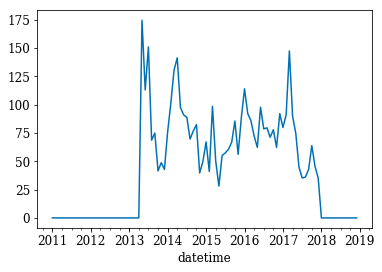

In [66]:
palm_data['observed bunch count (1/ha/month)'].plot()

In [67]:
data = pd.concat([df,palm_data],axis=1)

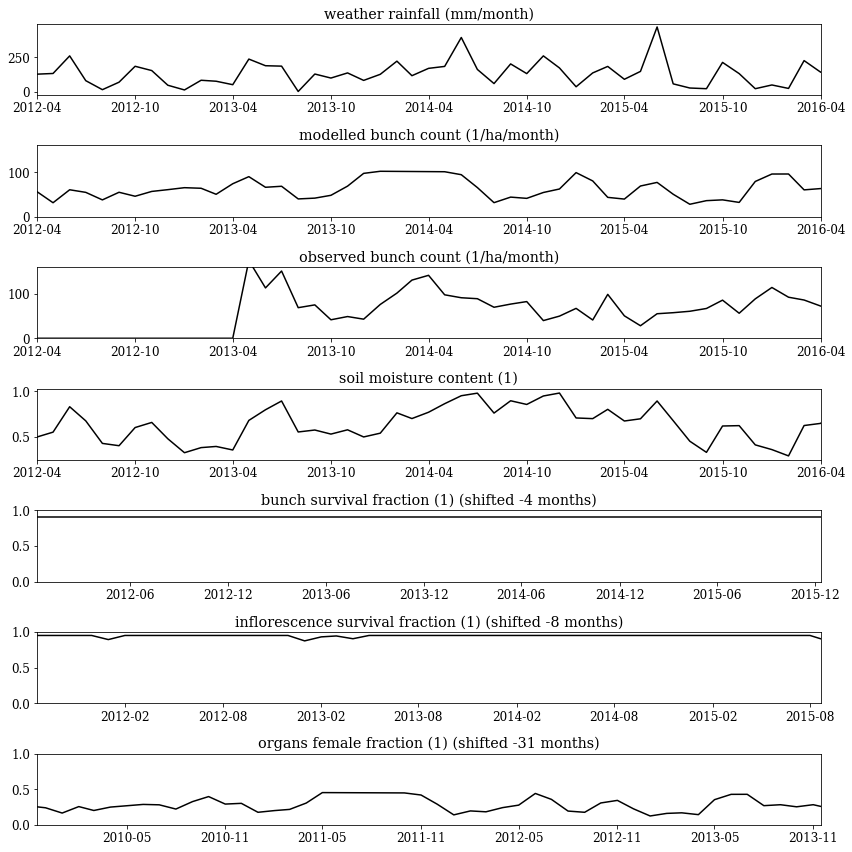

In [68]:
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['errorbar.capsize'] = 3

data['bunch survival fraction (1)'] = 1-data['organs bunch failure fraction (1)']
data['inflorescence survival fraction (1)'] = 1-data['organs inflorescence abortion fraction (1)']
data['modelled bunch count (1/ha/month)'] = data['organs bunch count (1/ha/month)']

recipes = [('weather rainfall (mm/month)',0,None),
           ('modelled bunch count (1/ha/month)',0,(0,160)),
           ('observed bunch count (1/ha/month)',0,(0,160)),
           ('soil moisture content (1)',0,None),
           ('bunch survival fraction (1)',4,(0,1)),
           ('inflorescence survival fraction (1)',8,(0,1)),
           ('organs female fraction (1)',31,(0,1)),           
          ]
           

f,axes = plt.subplots(len(recipes),figsize=(12,12))

import datetime

t0 = datetime.datetime(year=2012,month=4,day=1)
t1 = datetime.datetime(year=2016,month=4,day=1)

def make_timedelta(shift):
    return datetime.timedelta(weeks=4*shift)

for recipe,ax in zip(recipes,axes):
    
    try:

        c,shift,ylim = recipe

        x = data[c]
        ax.plot(x,color='black')

        timedelta=make_timedelta(shift)

        t0_ = t0-timedelta
        t1_ = t1-timedelta

        ax.set_ylim(ylim)
        ax.set_xlim(t0_,t1_)
        if shift == 0:
            ax.set_title(c)
        else:
            ax.set_title('{:} (shifted -{:} months)'.format(c,shift))

    except:
        pass
            
plt.tight_layout()

In [70]:
nans = data['observed bunch count (1/ha/month)'] == 0
data.loc[nans,'observed bunch count (1/ha/month)'] = np.nan

In [71]:
list(data)

['MAP',
 'assim fronds fraction (1)',
 'assim growth fronds (t/ha/month)',
 'assim growth generative (t/ha/month)',
 'assim growth roots (t/ha/month)',
 'assim growth total (t/ha/month)',
 'assim growth trunk (t/ha/month)',
 'assim growth vegetative (t/ha/month)',
 'assim maintenance fronds (t/ha/month)',
 'assim maintenance generative (t/ha/month)',
 'assim maintenance roots (t/ha/month)',
 'assim maintenance total (t/ha/month)',
 'assim maintenance trunk (t/ha/month)',
 'assim maintenance vegetative (t/ha/month)',
 'assim produced (t/ha/month)',
 'assim roots fraction (1)',
 'assim trunk fraction (1)',
 'date',
 'fronds assim growth (t/ha/month)',
 'fronds assim produced (t/ha/month)',
 'fronds count (1/ha)',
 'fronds count alt (1/palm)',
 'fronds count change rate (1/ha/month)',
 'fronds count growth rate (1/ha/month)',
 'fronds count loss rate (1/ha/month)',
 'fronds fraction intercepted (1)',
 'fronds initiation rate (1/palm/month)',
 'fronds leaf area (ha)',
 'fronds maintenance 

KeyError: 'soil moisture content'

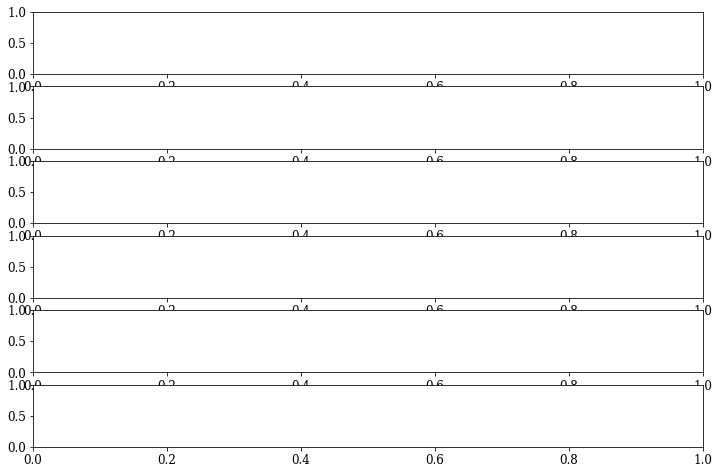

In [72]:
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['errorbar.capsize'] = 3

data['bunch survival fraction'] = 1-data['organs bunch failure fraction (1)']
data['inflorescence survival fraction'] = 1-data['organs inflorescence abortion fraction (1)']
data['modelled bunch count (1/ha)'] = data['organs bunch count (1/ha/month)']

data['female fraction (1)'] = data['organs female fraction (1)']

recipes = [('soil moisture content',0,None),
           ('bunch survival fraction (1)',4,(0,1)),
           ('inflorescence survival fraction (1)',8,(0,1)),
           ('female fraction (1)',31,(0,1)),
           ('modelled bunch count (1/ha/month)',0,(0,160)),
           ('observed bunch count (1/ha/month)',0,(0,160)),
          ]
           
f,axes = plt.subplots(len(recipes),figsize=(12,8))

import datetime

t0 = datetime.datetime(year=2010,month=4,day=1)
t1 = datetime.datetime(year=2016,month=4,day=1)

def make_timedelta(shift):
    return datetime.timedelta(weeks=4*shift)

for recipe,ax in zip(recipes,axes):
    c,shift,ylim = recipe
    
    x = data[c]
    ax.plot(x,color='black')
    
    if shift != 0:
        ax.plot(x.shift(shift),color='black',linestyle=':')
    
    ax.set_ylim(ylim)
    ax.set_xlim(t0,t1)
    if shift == 0:
        ax.set_title(c)
    else:
        ax.set_title('{:} (+{:} months lag)'.format(c,shift))
        
plt.tight_layout()
plt.savefig('bunch_dynamics.png',dpi=300)

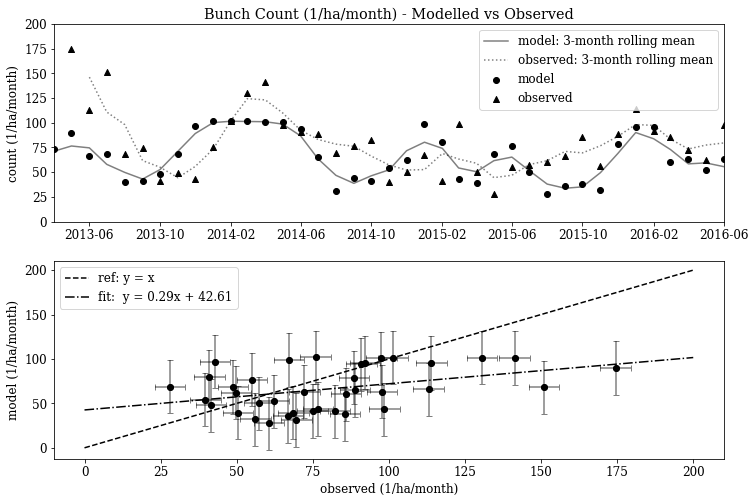

In [73]:
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['errorbar.capsize'] = 3

f,axes = plt.subplots(2,figsize=(12,8))

ax = axes[0]

ym = data['modelled bunch count (1/ha/month)']
yo = data['observed bunch count (1/ha/month)']

ymerr = 30
yoerr = 5

ax.set_title('Bunch Count (1/ha/month) - Modelled vs Observed')

ax.scatter(ym.index,ym.values,color='black',label='model')
#ax.errorbar(ym.index,ym.values,yerr=ymerr,fmt = 'o',color='black',alpha=0.5)
ax.plot(ym.rolling(3,center=True).mean(),color='black',alpha=0.5,label='model: 3-month rolling mean')

ax.scatter(yo.index,yo.values,color='black',marker='^',label='observed')
#ax.errorbar(yo.index,yo.values,yerr=yoerr,fmt = '^',color='black',alpha=0.5)
ax.plot(yo.rolling(3,center=True).mean(),color='black',alpha=0.5,linestyle=':',label='observed: 3-month rolling mean')

ax.legend()

ax.set_ylim(0,200)
ax.set_xlim('2013-4','2016-6')
ax.set_ylabel('count (1/ha/month)')

ax = axes[1]

series = pd.concat([ym,yo],axis=1).loc['2013-5':'2016-6'].values

ym = series[:,0]
yo = series[:,1]

from scipy.optimize import curve_fit

func1 = lambda x,a,b: a*x + b
func2 = lambda x,a: a*x

popt1,pcov = curve_fit(func1,yo,ym)
popt2,pcov = curve_fit(func2,yo,ym)

x = np.linspace(0,200)
yf1 = func1(x,*popt1)
yf2 = func2(x,*popt2)

ax.plot([0,200],[0,200],color='black',linestyle='dashed',label='ref: y = x')
ax.plot(x,yf1,color='black',linestyle='-.',label='fit:  y = {:3.2f}x + {:3.2f}'.format(*popt1))

ax.scatter(yo,ym,color='black')
ax.errorbar(yo,ym,xerr=yoerr,yerr=ymerr,fmt='o',color='black',alpha=0.5)
ax.set_xlabel('observed (1/ha/month)')
ax.set_ylabel('model (1/ha/month)')

ax.legend(framealpha=0.8)

plt.savefig('preliminary_model_performance.png',dpi=300)

In [ ]:
#series.to_csv('bunch_counts.csv',index_label='datetime')